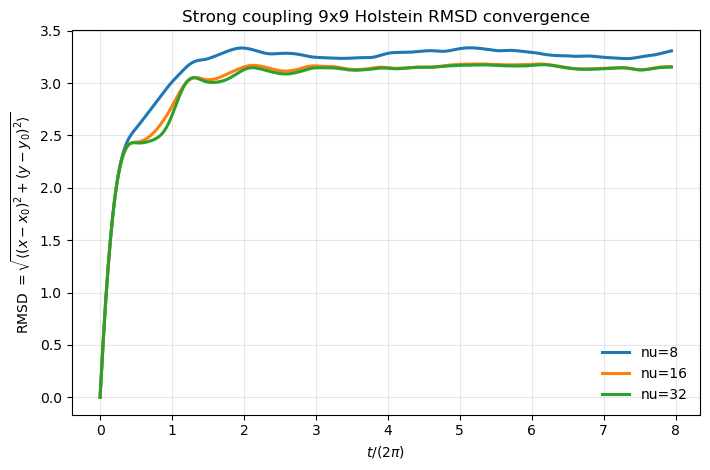

,nu,n_time,path
0,8,500,Holstein_99_nu8/multiset/H99_2D_m64_nu.npz
1,16,500,Holstein_99_nu16/multiset/H99_2D_m64_nu.npz
2,32,500,Holstein_99_nu32/multiset/H99_2D_m64_nu.npz


In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run this notebook either from this directory or from the repository root.
BASE_DIR = Path.cwd()
if not (BASE_DIR / "Holstein_99_nu8").exists():
    candidate = Path("multiset_202606/2DHolstein_nu_convergencetest/strongcoupling")
    BASE_DIR = candidate if candidate.exists() else BASE_DIR

CASES = [
    (8, "$nu=8$", BASE_DIR / "Holstein_99_nu8" / "multiset"),
    (16, "nu=16", BASE_DIR / "Holstein_99_nu16" / "multiset"),
    (32, "nu=32", BASE_DIR / "Holstein_99_nu32" / "multiset"),
]

GRID_SIZE = 9
TIME_DIVISOR = 2 * np.pi
RESULT_STEM = "H99_2D_m64_nu"


def compute_rmsd_2d(occupations, size=GRID_SIZE):
    occupations = np.asarray(occupations, dtype=float)
    nsite = occupations.shape[1]
    if size is None or size * size != nsite:
        inferred = int(round(np.sqrt(nsite)))
        if inferred * inferred != nsite:
            raise ValueError(f"cannot infer square grid from {nsite} sites")
        size = inferred
    yy, xx = np.indices((size, size), dtype=float)
    center = (size - 1) / 2
    dist2 = ((xx - center) ** 2 + (yy - center) ** 2).reshape(-1)
    norm = occupations.sum(axis=1, keepdims=True)
    rho = np.divide(occupations, norm, out=np.zeros_like(occupations), where=norm > 0)
    return np.sqrt((rho * dist2).sum(axis=1))


def read_npz(path):
    with np.load(path, allow_pickle=True) as data:
        time = np.asarray(data["time_series"], dtype=float)
        occupations = np.asarray(np.real_if_close(data["e_occupations"]), dtype=float)
    return time, occupations


def read_xlsx(path):
    xls = pd.ExcelFile(path)
    if "populations" in xls.sheet_names:
        df = pd.read_excel(path, sheet_name="populations")
        site_cols = [col for col in df.columns if str(col).startswith("site_")]
        if site_cols:
            time = pd.to_numeric(df["time"], errors="coerce").to_numpy(dtype=float)
            occupations = df[site_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
            return time, np.nan_to_num(occupations)
    df = pd.read_excel(path, sheet_name=xls.sheet_names[0], header=None)
    arr = df.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    arr = np.nan_to_num(arr[~np.all(np.isnan(arr), axis=1)])
    time = np.arange(arr.shape[0], dtype=float) * 0.1
    return time, arr


def load_case(run_dir):
    npz_path = run_dir / f"{RESULT_STEM}.npz"
    xlsx_path = run_dir / f"{RESULT_STEM}.xlsx"
    if npz_path.exists():
        time, occupations = read_npz(npz_path)
        return time, compute_rmsd_2d(occupations), npz_path
    if xlsx_path.exists():
        time, occupations = read_xlsx(xlsx_path)
        return time, compute_rmsd_2d(occupations), xlsx_path
    return None


fig, ax = plt.subplots(figsize=(7.2, 4.8))
summary = []

for nu, label, run_dir in CASES:
    loaded = load_case(run_dir)
    if loaded is None:
        print(f"[missing] {label}: no {RESULT_STEM}.npz/.xlsx under {run_dir}")
        continue
    time, rmsd, path = loaded
    n = min(len(time), len(rmsd))
    ax.plot(
        np.asarray(time[:n], dtype=float) / TIME_DIVISOR,
        rmsd[:n],
        linewidth=2.2,
        label=label,
    )
    summary.append({
        "nu": nu,
        "n_time": n,
        "path": str(path.relative_to(BASE_DIR)),
    })

ax.set_title("Strong coupling 9x9 Holstein RMSD convergence")
ax.set_xlabel(r"$t/(2\pi)$")
ax.set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary)
summary_df
